IMPORTACIÓN DE LIBRERÍAS 

----

In [17]:
# Manejo de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

# Preprocesamiento (¡VITAL en no supervisado!)
from sklearn.preprocessing import StandardScaler

# Modelos de Clustering y PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Métricas y Dendrograma
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [18]:
df = pd.read_csv('datasets/Social_media_impact_on_life.csv')

print(f"Este dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")


Este dataset tiene 1705 filas y 11 columnas.


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 146.7 KB


In [20]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


In [21]:
df.isnull().sum() 

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [22]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


fijarse en los duplicados !!

In [23]:
df.duplicated().sum()

np.int64(0)

----- 
VISUAL EDA

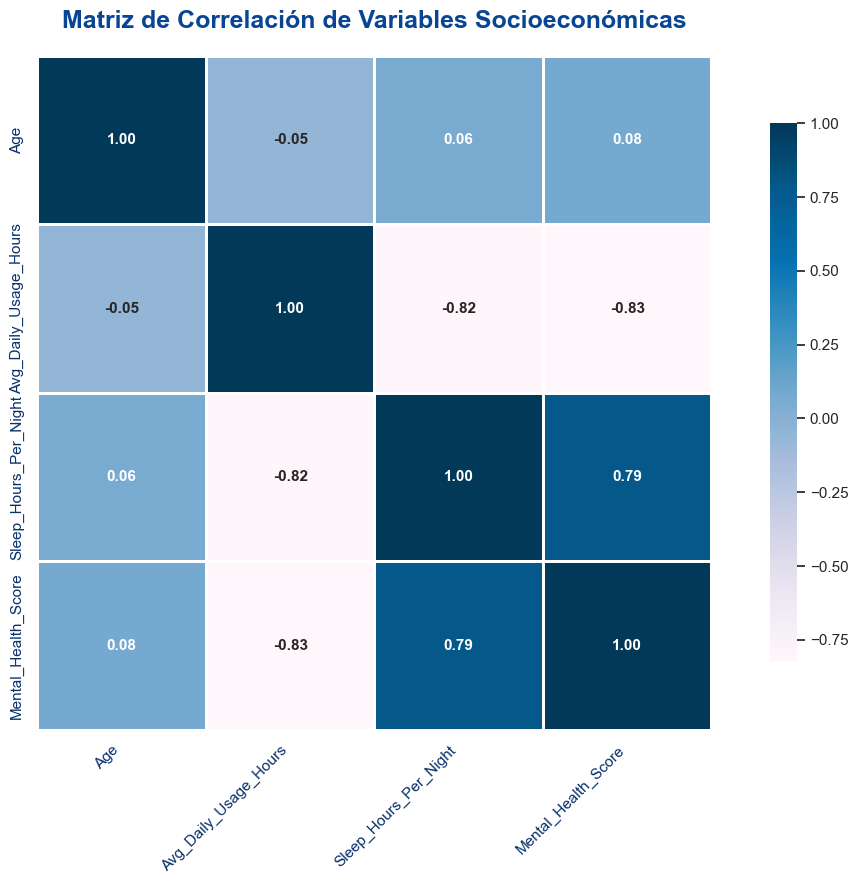

In [24]:
sns.set_theme(style="white")
# recordar que 'Student_ID' es un identificador único, no una variable numérica relevante para el análisis de correlación
# solo seleccionamos las columnas numéricas relevantes para la matriz de correlación
numeric_df = df.select_dtypes(include=np.number).drop('Student_ID', axis=1, errors='ignore')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix, 
    annot=True,                              
    cmap='PuBu',                            
    fmt=".2f",                               
    linewidths=1,                        
    linecolor='white',                    
    cbar_kws={"shrink": .8},                 
    square=True,                            
    annot_kws={"size": 11, "weight": "bold"} 
)

plt.title('Matriz de Correlación de Variables Socioeconómicas', 
        fontsize=18, fontweight='bold', color='#084594', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11, color='#08306b')
plt.yticks(fontsize=11, color='#08306b')

plt.tight_layout()
plt.show()

tenemos correlaciones fuertes se podria aplicar pca...

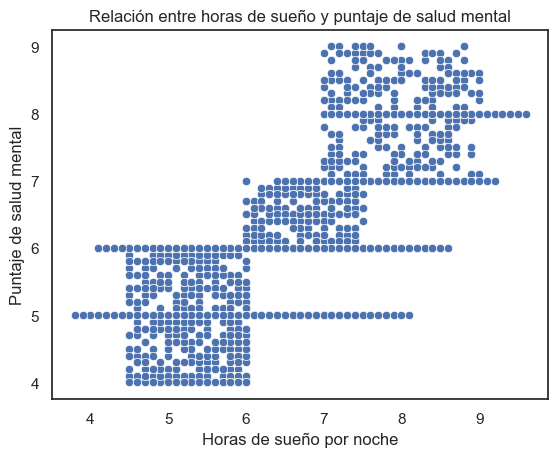

In [25]:
sns.scatterplot(data=df, x="Sleep_Hours_Per_Night", y="Mental_Health_Score")
plt.title("Relación entre horas de sueño y puntaje de salud mental")
plt.xlabel("Horas de sueño por noche")
plt.ylabel("Puntaje de salud mental")
plt.show()          

fijarse en las columnas por ejemplo este caso el student_id no es algo que necesitamos solo para saber que persona es entoces 

In [26]:
df.set_index('Student_ID', inplace=True)

como tenemos columnas categoricas tendremos que transformalas ya que la ia solo entiende NUMEROS 

In [27]:
df = pd.get_dummies(df, drop_first=True)
# usamos dummies cuando tenemos variables categóricas, para convertirlas en numéricas

ahora escalamos ya que se basa en distancias euclideas

In [28]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)

pasamos a seleccionar el valor de k de numeros de clusteres a través de el metodo codo que se basa en la funcion de inercia y luego el silhoutte score 

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

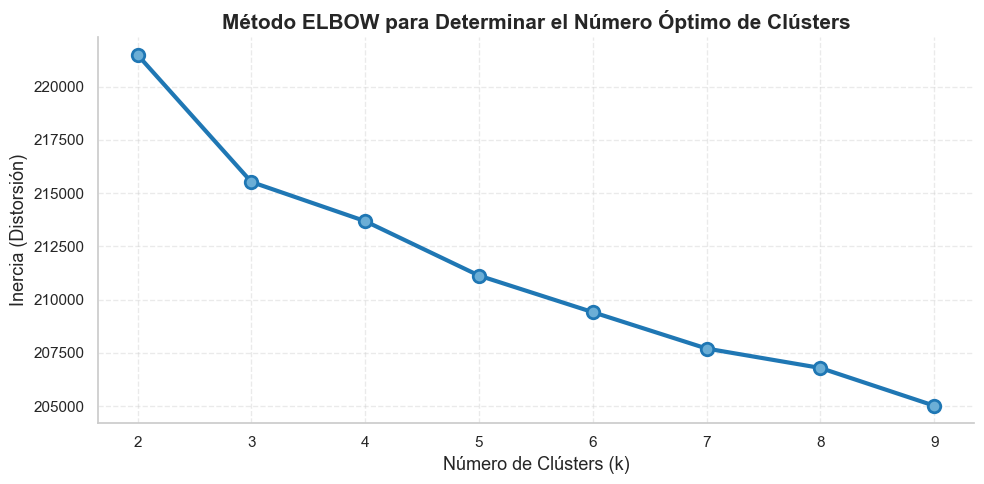

In [29]:

sns.set_style("whitegrid")
distortions = []
K_range = range(2, 10)

for k in K_range:
    kmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeanModel.fit(df_scaled)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    K_range,
    distortions,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Inercia (Distorsión)", fontsize=13)
plt.title("Método ELBOW para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

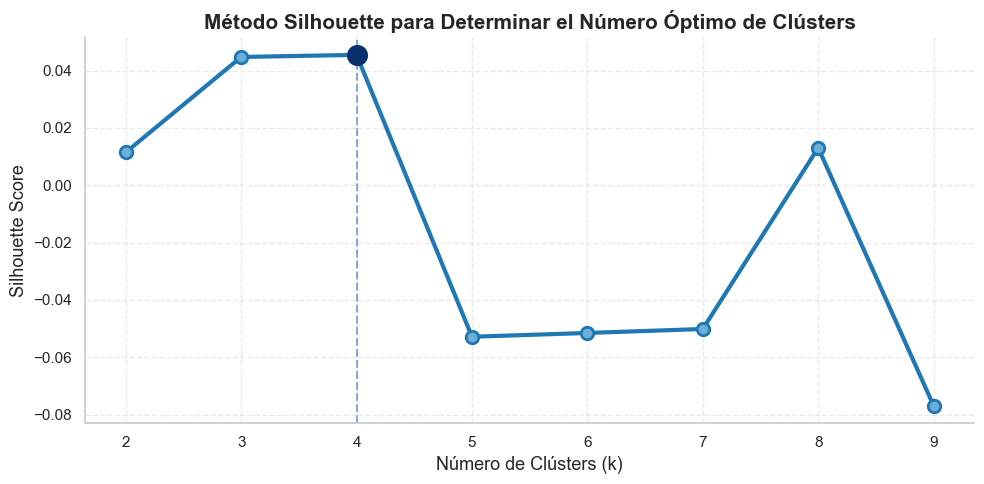

In [30]:
sns.set_style("whitegrid")

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(df_scaled)
    score = silhouette_score(df_scaled, kmeans.labels_, metric='euclidean')
    scores.append(score)

scores = np.array(scores)

best_k = list(K_range)[scores.argmax()]
best_score = scores.max()

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    list(K_range),
    scores,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

#esto es para resaltar el mejor k
plt.scatter(best_k, best_score, s=200, color="#08306b", zorder=3)
plt.axvline(best_k, linestyle="--", alpha=0.6)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Método Silhouette para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

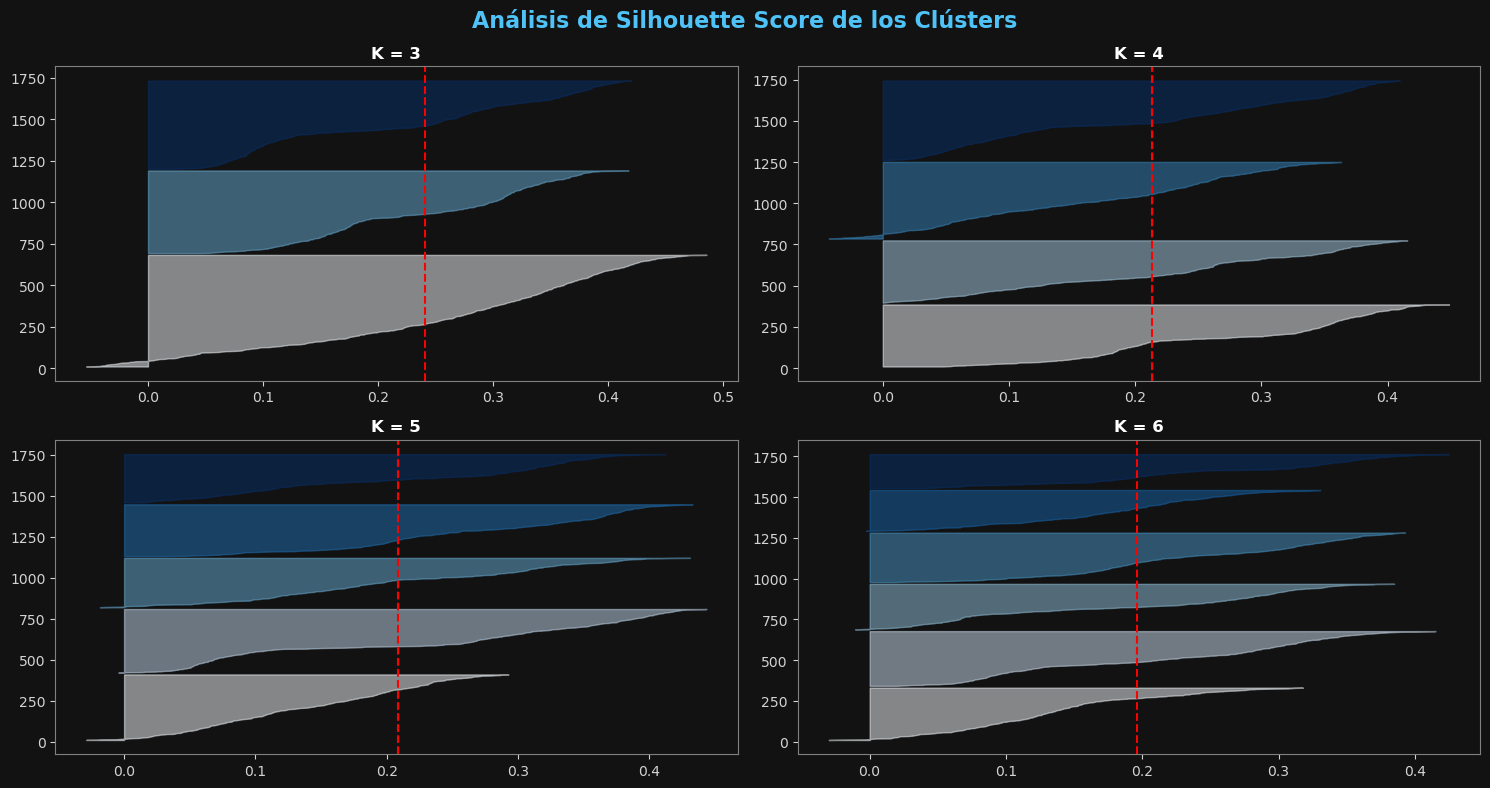

In [ ]:


plt.style.use('dark_background')

fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig.patch.set_facecolor('#121212') 

k_values = [3, 4, 5, 6]

for i, k in enumerate(k_values):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    
    fila = i // 2
    columna = i % 2
    
    ax[fila][columna].set_facecolor('#121212')
    
    # Al usar 'Blues' sobre fondo negro, los azules resaltarán muchísimo más
    visualizer = SilhouetteVisualizer(km, colors='Blues', ax=ax[fila][columna])
    
    visualizer.fit(df)
    
    ax[fila][columna].set_title(f"K = {k}", color="white", fontsize=12, weight="bold")
    
    ax[fila][columna].tick_params(colors='lightgray')
    for spine in ax[fila][columna].spines.values():
        spine.set_color('gray')

fig.suptitle("Análisis de Silhouette Score de los Clústers", color="#4fc3f7", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

plt.style.use('default')

duda aqui en el visualizer s ele pasa el df esclado o no porque si se lo pasa escaldo muestra cosas raras. !!!!

segun las graficas vistas creo que lo mas optimo est omar elññ k 4 ya que esta mas o menos del mismo grosor los clusters 

In [33]:
k = 4 

In [ ]:
kmeans = KMeans(n_clusters=k, n_init='auto', init='k-means++', random_state=30)
